In [1]:
import os
print(f"Current Directory: {os.getcwd()}")
os.chdir("..")
print(f"New Directory: {os.getcwd()}")

Current Directory: c:\Users\mattc\Documents\DL-reservoir-modeling\additional_experiments
New Directory: c:\Users\mattc\Documents\DL-reservoir-modeling


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.basemap import Basemap
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from math import floor
import os
import copy
from scipy import stats
from scipy.stats import theilslopes
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
import seaborn as sns
import re

from src.data.data_processing import *
from src.data.data_fetching import *
from src.models.model_zoo import *
from src.models.predict_model import *
from src.models.train_model import *
from src.models.hyperparameter_tuning import *
from src.models.analyze_lstm_cell import *

# Evaluate Performance in Simulatneous (Pooled) Training

## Performance in out-of-sample reservoirs
A simulatenous pooled training model was trained on 70% of randomly selected reservoirs (in-sample reservoirs) and tested against the remaining 30% reservoirs (out-of-sample reservoirs). For in-sample reservoirs, training is done using a 75% training and 25% validation split (for early stopping)

In [3]:
# Read data
in_sample_r2 = pd.read_csv('report/results/additional_experiments/hyperparameter_tuning_pooled/resops_oos_in_sample_train_val.csv', index_col=0)
out_of_sample_r2 = pd.read_csv('report/results/additional_experiments/hyperparameter_tuning_pooled/resops_oos_out_of_sample_test.csv', index_col=0)

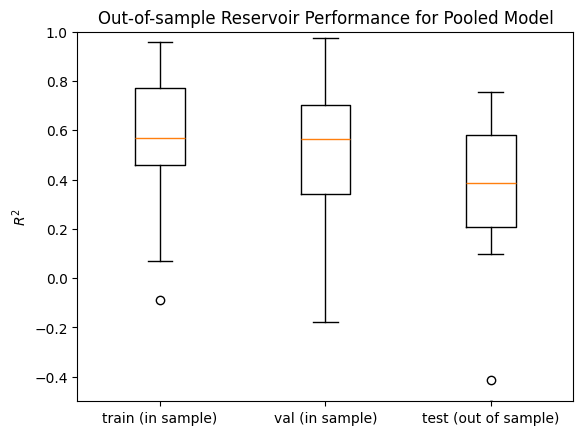

In [4]:
fig, ax = plt.subplots()
ax.boxplot([in_sample_r2['train'], 
            in_sample_r2['val'],
            out_of_sample_r2.values.flatten()], tick_labels=['train (in sample)',
                                       'val (in sample)',
                                       'test (out of sample)'])
ax.set_ylim(-0.5, 1)
ax.set_title('Out-of-sample Reservoir Performance for Pooled Model')
ax.set_ylabel('$R^2$')
plt.show()

## Finetuning performance
The multi-reservoir reservoir model is then fine-tuned using the first n years of the record (training 75%, validation 25% of those n year) and tested using the last 20% of the complete record (same as the test set for individual training experiments). These finetuned models are then compared to individual training and to the multi-reservoir model with no finetuning.

In [5]:
# Read data
finetuning_r2 = pd.read_csv('report/results/additional_experiments/hyperparameter_tuning_pooled/resops_oos_finetuning.csv', index_col=0)
finetuning_r2.head()

,individual,pooled,finetuned_pooled_5yr,finetuned_pooled_10yr,finetuned_pooled_15yr,finetuned_pooled_20yr,finetuned_pooled_25yr,finetuned_pooled_30yr
307,0.049155,0.303551,0.012434,0.042505,-0.010737,0.012138,0.073489,0.063558
1067,0.406108,0.402221,-0.553631,0.376084,0.362044,0.485673,0.424744,0.402346
938,0.249014,0.271974,0.294208,0.006900,-0.232111,0.146737,0.265035,0.352611
601,-0.058900,-0.271433,-0.941665,-0.406919,-0.270246,-0.177433,0.068439,-0.045980
293,0.696195,0.498235,0.571251,0.589715,0.582114,0.698325,0.734141,0.775622


In [6]:
finetuning_r2.median()

individual               0.576805
pooled                   0.395426
finetuned_pooled_5yr     0.430892
finetuned_pooled_10yr    0.480900
finetuned_pooled_15yr    0.532317
finetuned_pooled_20yr    0.569253
finetuned_pooled_25yr    0.525866
finetuned_pooled_30yr    0.541544
dtype: float64

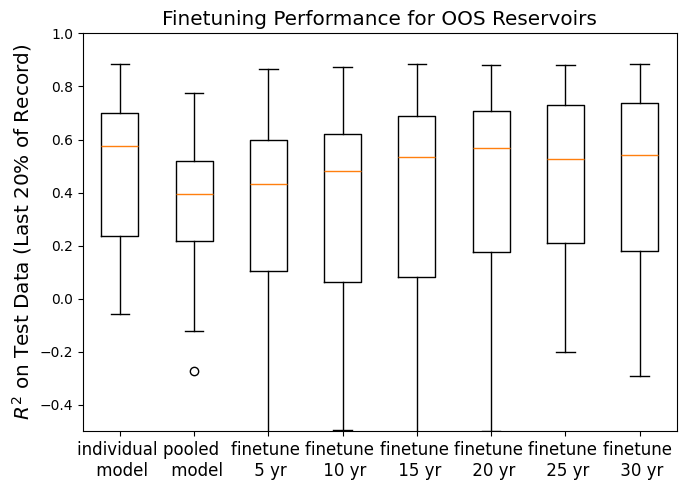

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
# Create boxplot
bp = ax.boxplot(finetuning_r2, tick_labels=['individual \n model',
                                  'pooled \n model',
                                  'finetune \n 5 yr',
                                  'finetune \n 10 yr',
                                  'finetune \n 15 yr',
                                  'finetune \n 20 yr',
                                  'finetune \n 25 yr',
                                  'finetune \n 30 yr'])

ax.set_ylim(-0.5, 1)
ax.set_title('Finetuning Performance for OOS Reservoirs', size='x-large')
ax.set_ylabel('$R^2$ on Test Data (Last 20% of Record)', size='x-large')
plt.setp(ax.get_xticklabels(), size='large')
plt.tight_layout()
plt.savefig('report/results/additional_experiments/hyperparameter_tuning_pooled/finetuning_resops.png', dpi=300)
plt.show()

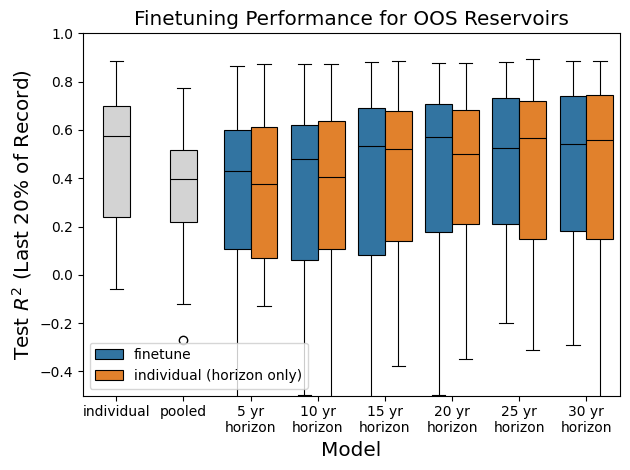

In [8]:
# Compare finetuning to no pretraining on same data (denoted as baseline)

# Read baseline data
baseline_r2 = pd.read_csv('report/results/additional_experiments/hyperparameter_tuning_pooled/resops_oos_finetuning_baseline.csv', index_col=0)


def finetune_df_to_long(df: pd.DataFrame, group_label: str) -> pd.DataFrame:
    """
    Convert a wide df to long form with columns mapped to a 'category' (years)
    and rows as 'value'. Unmatched columns are skipped.
    """
    # Regex to find one of the years as a standalone number chunk (e.g. handles "finetuned_pooled_5yr")
    year_re = re.compile(r'(?<!\d)(5|10|15|20|25|30)(?!\d)')

    records = []
    for col in df.columns:
        # Build rows: each non-NA entry in this column becomes one record
        col_values = df[col].dropna()
        if len(col_values) == 0:
            continue

        m = year_re.search(str(col))
        if not m:
            category = col
            group = "plain"
        else:
            category = f"{int(m.group(0))} yr\nhorizon"
            group = group_label

        records.append(pd.DataFrame({
            "category": category,
            "group": group,
            "value": col_values.values
        }))
    return pd.concat(records, ignore_index=True) if records else pd.DataFrame(columns=["category", "group", "value"])

# Build long-form from both sources
long_finetune = finetune_df_to_long(finetuning_r2, "finetune")
long_baseline = finetune_df_to_long(baseline_r2, "individual (horizon only)")
long_df = pd.concat([long_finetune, long_baseline], ignore_index=True)

palette = {
    "finetune": sns.color_palette()[0],
    "individual (horizon only)": sns.color_palette()[1],
    "plain": "lightgrey"
}


cat_order = list(pd.unique(long_df["category"])) # Desired category order
plain_df = long_df[long_df["group"] == "plain"] # Split data: pooled and individual
non_plain = long_df[long_df["group"] != "plain"] # Split data: finetune and baseline
# Common outline settings
common_kws = dict(linewidth=0.8, boxprops=dict(edgecolor="black"), whiskerprops=dict(color="black"), capprops=dict(color="black"),
    medianprops=dict(color="black"), flierprops=dict(markeredgecolor="black", markerfacecolor="none"))

fig, ax = plt.subplots()

# 1) finetune/baseline (dodged)
sns.boxplot(data=non_plain, x="category", y="value", hue="group", palette=palette, order=cat_order, ax=ax, width=0.8, **common_kws)
# 2) plain (centered)
if not plain_df.empty:
    sns.boxplot(data=plain_df, x="category", y="value", color=palette["plain"], order=cat_order, ax=ax, width=0.4, **common_kws)

ax.set_ylim(-0.5, 1)
ax.set_ylabel('Test $R^2$ (Last 20% of Record)', size='x-large')
ax.set_xlabel("Model", size='x-large')
ax.set_title('Finetuning Performance for OOS Reservoirs', size='x-large')
handles, labels = ax.get_legend_handles_labels()
keep = [i for i, lab in enumerate(labels) if lab != "plain"]
ax.legend([handles[i] for i in keep], [labels[i] for i in keep], title=None)
plt.tight_layout()
plt.savefig('report/results/additional_experiments/hyperparameter_tuning_pooled/finetuning_vs_baseline.png', dpi=300)
plt.show()

In [9]:
non_plain.groupby(['category', 'group']).median()

value
category       group                              
10 yr\nhorizon finetune                   0.480900
               individual (horizon only)  0.406540
15 yr\nhorizon finetune                   0.532317
               individual (horizon only)  0.522963
20 yr\nhorizon finetune                   0.569253
               individual (horizon only)  0.500123
25 yr\nhorizon finetune                   0.525866
               individual (horizon only)  0.565006
30 yr\nhorizon finetune                   0.541544
               individual (horizon only)  0.557156
5 yr\nhorizon  finetune                   0.430892
               individual (horizon only)  0.375813

In [10]:
# Number of OOS reservoirs
len(finetuning_r2)

35